In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load raw data

In [46]:
#Load data
spotify_df = pd.read_csv('../data/raw/spotify_user_behavior.csv')

print(f"\nDataset shape: {spotify_df.shape}")
print(f"\nData types:\n{spotify_df.dtypes}\n")
spotify_df.head()


Dataset shape: (50000, 18)

Data types:
user_id                             int64
country                            object
age                                 int64
signup_date                        object
subscription_type                  object
subscription_status                object
months_inactive                     int64
inactive_3_months_flag              int64
ad_interaction                     object
ad_conversion_to_subscription      object
music_suggestion_rating_1_to_5      int64
avg_listening_hours_per_week      float64
favorite_genre                     object
most_liked_feature                 object
desired_future_feature             object
primary_device                     object
playlists_created                   int64
avg_skips_per_day                   int64
dtype: object



,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


### Initial data exploration

In [47]:
#Dataset info
print("\nDataset info:")
spotify_df.info()

#Summary statistics
print("\nSummary statistics:")
display(spotify_df.describe())



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         50000 non-null  int64  
 1   country                         50000 non-null  object 
 2   age                             50000 non-null  int64  
 3   signup_date                     50000 non-null  object 
 4   subscription_type               50000 non-null  object 
 5   subscription_status             50000 non-null  object 
 6   months_inactive                 50000 non-null  int64  
 7   inactive_3_months_flag          50000 non-null  int64  
 8   ad_interaction                  50000 non-null  object 
 9   ad_conversion_to_subscription   50000 non-null  object 
 10  music_suggestion_rating_1_to_5  50000 non-null  int64  
 11  avg_listening_hours_per_week    50000 non-null  float64
 12  favorite_genre   

,user_id,age,months_inactive,inactive_3_months_flag,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,playlists_created,avg_skips_per_day
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,38.010280,1.533020,0.222460,3.644100,9.988986,8.002680,10.025920
std,14433.901067,12.984989,1.952082,0.415903,1.114424,3.968927,2.831571,3.165579
min,1.000000,16.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,12500.750000,27.000000,0.000000,0.000000,3.000000,7.280000,6.000000,8.000000
50%,25000.500000,38.000000,1.000000,0.000000,4.000000,9.980000,8.000000,10.000000
75%,37500.250000,49.000000,2.000000,0.000000,5.000000,12.680000,10.000000,12.000000
max,50000.000000,60.000000,18.000000,1.000000,5.000000,26.250000,23.000000,25.000000


### Explore characteristics of raw data

In [48]:
#Subscription status distribution
#To be used as target feature
print("\nSubscription status distribution:")
print(spotify_df['subscription_status'].value_counts())

#Subscription type distribution
print("\nSubscription type distribution:")
print(spotify_df['subscription_type'].value_counts())

#Earliest and latest signup dates
print("\nEarliest signup date:", spotify_df['signup_date'].min())
print("Latest signup date:", spotify_df['signup_date'].max())

#Primary device distribution
print("\nPrimary device distribution:")
print(spotify_df['primary_device'].value_counts())


Subscription status distribution:
subscription_status
Active      42109
Inactive     7891
Name: count, dtype: int64

Subscription type distribution:
subscription_type
Free                  22525
Premium Individual    14029
Student                4516
Premium Family         4482
Premium Duo            4448
Name: count, dtype: int64

Earliest signup date: 2018-01-01
Latest signup date: 2026-03-01

Primary device distribution:
primary_device
Smart Speaker    10050
Car System       10044
Desktop          10037
Mobile            9937
Tablet            9932
Name: count, dtype: int64


### Exploratory data analysis


Subscription status by subscription type:
subscription_status    Active  Inactive
subscription_type                      
Free                 0.844040  0.155960
Premium Duo          0.838129  0.161871
Premium Family       0.840696  0.159304
Premium Individual   0.843182  0.156818
Student              0.835252  0.164748

Subscription status by 3 month inactive flag:
subscription_status       Active  Inactive
inactive_3_months_flag                    
0                       1.000000       NaN
1                       0.290569  0.709431

Subscription type by 3 month inactive flag:
subscription_type           Free  Premium Duo  Premium Family  \
inactive_3_months_flag                                          
0                       0.452247     0.088176        0.089333   
1                       0.444394     0.091702        0.090713   

subscription_type       Premium Individual   Student  
inactive_3_months_flag                                
0                                 0.280217

Text(0.5, 1.0, 'Churn Rate by Number of Months Inactive')

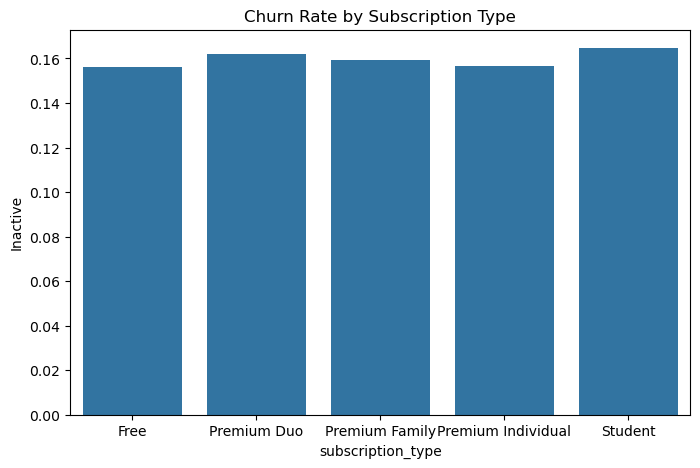

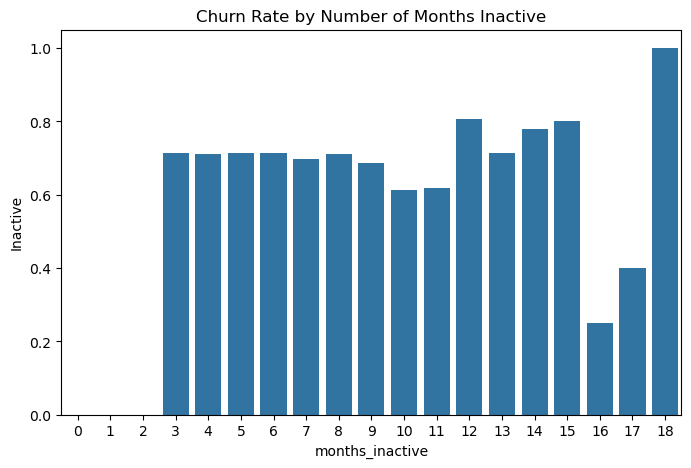

In [49]:
#Subscription status by subscription type
print("\nSubscription status by subscription type:")
subscription_status_by_type = spotify_df.groupby('subscription_type')['subscription_status'].value_counts(normalize=True).unstack()
print(subscription_status_by_type)

#Subscription status by months inactive flag
print("\nSubscription status by 3 month inactive flag:")
subscription_status_by_inactive_flag = spotify_df.groupby('inactive_3_months_flag')['subscription_status'].value_counts(normalize=True).unstack()
print(subscription_status_by_inactive_flag)

#Subscription type by months inactive flag
print("\nSubscription type by 3 month inactive flag:")
subscription_type_by_inactive_flag = spotify_df.groupby('inactive_3_months_flag')['subscription_type'].value_counts(normalize=True).unstack()
print(subscription_type_by_inactive_flag)

#Plot churn rate by subscription type
plt.figure(figsize=(8, 5))
sns.barplot(x=subscription_status_by_type.index, y=subscription_status_by_type['Inactive'])
plt.title('Churn Rate by Subscription Type')

#Plot churn rate by number of months inactive
subscription_status_by_inactive = spotify_df.groupby('months_inactive')['subscription_status'].value_counts(normalize=True).unstack()
plt.figure(figsize=(8, 5))
sns.barplot(x=subscription_status_by_inactive.index, y=subscription_status_by_inactive['Inactive'])
plt.title('Churn Rate by Number of Months Inactive')

### Data Cleaning

In [50]:
#Convert yes/no columns to binary
spotify_df['ad_interaction'] = spotify_df['ad_interaction'].map({'Yes': 1, 'No': 0}).astype(int)
spotify_df['ad_conversion_to_subscription'] = spotify_df['ad_conversion_to_subscription'].map({'Yes': 1, 'No': 0}).astype(int)

#Rename subscription status to 'churn' for clear target variable (1 for Inactive, 0 for Active)
spotify_df.rename(columns={'subscription_status': 'churn'}, inplace=True)
spotify_df['churn'] = spotify_df['churn'].replace({'Active': 0, 'Inactive': 1})

#Convert signup_date to datetime
spotify_df['signup_date'] = pd.to_datetime(spotify_df['signup_date'])

#Sort by signup date
spotify_df = spotify_df.sort_values('signup_date')

#Convert categorical variables to category dtype
spotify_df['country'] = spotify_df['country'].astype('category')
spotify_df['subscription_type'] = spotify_df['subscription_type'].astype('category')
spotify_df['primary_device'] = spotify_df['primary_device'].astype('category')
spotify_df['favorite_genre'] = spotify_df['favorite_genre'].astype('category')
spotify_df['most_liked_feature'] = spotify_df['most_liked_feature'].astype('category')
spotify_df['desired_future_feature'] = spotify_df['desired_future_feature'].astype('category')

#Drop original subscription_status column to prevent confusion

#Check data types before saving
print("\nData types after cleaning:")
print(spotify_df.dtypes)



Data types after cleaning:
user_id                                    int64
country                                 category
age                                        int64
signup_date                       datetime64[ns]
subscription_type                       category
churn                                      int64
months_inactive                            int64
inactive_3_months_flag                     int64
ad_interaction                             int64
ad_conversion_to_subscription              int64
music_suggestion_rating_1_to_5             int64
avg_listening_hours_per_week             float64
favorite_genre                          category
most_liked_feature                      category
desired_future_feature                  category
primary_device                          category
playlists_created                          int64
avg_skips_per_day                          int64
dtype: object


C:\Users\megan\AppData\Local\Temp\ipykernel_21508\1525238630.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  spotify_df['churn'] = spotify_df['churn'].replace({'Active': 0, 'Inactive': 1})


In [ ]:
#Save cleaned dataset
spotify_df.to_parquet('../data/processed/spotify_user_behavior_cleaned.parquet', index=False)